In [79]:
import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt

In [80]:
ops.wipe()

In [81]:
# --- Units (consistent set) ---
# Length: m, Force: N, Stress: Pa (N/m^2), Density: kg/m^3

# --- Geometry ---
Lx = 6.0   # frame length in x
Ly = 4.0   # frame length in y
H  = 3.0   # column height (z)

# Corner node coordinates (rectangular plan)
coords = {
    1: (0.0, 0.0, 0.0),    # base nodes
    2: (Lx, 0.0, 0.0),
    3: (Lx, Ly, 0.0),
    4: (0.0, Ly, 0.0),
    5: (0.0, 0.0, H),      # top nodes
    6: (Lx, 0.0, H),
    7: (Lx, Ly, H),
    8: (0.0, Ly, H),
}

# --- Material/Section (steel-like example; adjust as needed) ---
E  = 200e9      # Young's modulus (Pa)
G  = 79.3e9     # Shear modulus (Pa), ~E/(2*(1+nu)) with nu≈0.26
rho = 7850      # Density (kg/m^3), optional if you add mass

A_col = 0.02    # Column area (m^2)
Iy_col = 1.6e-4 # Column second moment about local y (m^4)
Iz_col = 1.6e-4 # Column second moment about local z (m^4)
J_col  = 3.2e-4 # Torsion constant (m^4), rough

A_beam = 0.015
Iy_beam = 1.2e-4
Iz_beam = 1.2e-4
J_beam  = 2.4e-4

# Optional lumped mass at top nodes (for future dynamic work)
m_top = 500.0   # kg per top node


In [82]:
# 1) Define model builder
ops.model('basic', '-ndm', 3, '-ndf', 6)  # 3D, 6 dof per node

# 2) Create nodes
for tag, (x, y, z) in coords.items():
    ops.node(tag, x, y, z)

# 3) Fix base nodes (all DOF)
for base_node in [1, 2, 3, 4]:
    ops.fix(base_node, 1, 1, 1, 1, 1, 1)

# 4) Optional: lumped masses at top nodes (rx, ry, rz masses zero by default)
for top_node in [5, 6, 7, 8]:
    ops.mass(top_node, m_top, m_top, m_top, 0.0, 0.0, 0.0)

# 5) Geometric transformations
# Use Linear for small-displacement analysis; define local axes via a vector
# For vertical columns: local x along element (node i->j). Use vec to orient local y/z.
# We'll use global Y as a reference vector to define local axes consistently.
ops.geomTransf('Linear', 1, 0, 1, 0)  # transfTag=1: columns (local y tends toward global Y)
ops.geomTransf('Linear', 2, 0, 0, 1)  # transfTag=2: beams (local y tends toward global Z)


In [83]:
# Helper to create elastic beam-column elements
def add_elastic_beam_col(el_tag, i, j, A, E, G, J, Iy, Iz, transf_tag):
    ops.element('elasticBeamColumn', el_tag, i, j, A, E, G, J, Iy, Iz, transf_tag)

# 6) Columns (1-5, 2-6, 3-7, 4-8)
elements = {}
col_pairs = [(1,5), (2,6), (3,7), (4,8)]
tag = 1
for i, j in col_pairs:
    add_elastic_beam_col(tag, i, j, A_col, E, G, J_col, Iy_col, Iz_col, 1)
    elements[tag] = (i, j)
    tag += 1

# 7) Top perimeter beams: 5-6 (x), 6-7 (y), 7-8 (x), 8-5 (y)
beam_pairs = [(5,6), (6,7), (7,8), (8,5)]
for i, j in beam_pairs:
    add_elastic_beam_col(tag, i, j, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
    elements[tag] = (i, j)
    tag += 1


In [84]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

# 8) Gravity (nodal, approximate)
g = 9.81
for top_node in [5, 6, 7, 8]:
    # Nodal weight: m_top * g downward in Z
    ops.load(top_node, 0.0, 0.0, -m_top * g, 0.0, 0.0, 0.0)

# 9) Lateral load at node 6
Fx = 10e3  # 10 kN
Fy = 10  # 10 kN
ops.load(6, Fx, Fy, 0.0, 0.0, 0.0, 0.0)

# 10) Analysis options
#ops.test('NormUnbalance', 1e-1, 20)

ops.constraints('Plain')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.test('NormUnbalance', 1e-12, 20)
ops.algorithm('Newton')

#ops.algorithm('NewtonLineSearch', 0.8)
ops.integrator('LoadControl', 0.1)
ops.analysis('Static')

ok = ops.analyze(1)
print("Analysis result:", "OK" if ok == 0 else f"FAILED (code {ok})")


Analysis result: OK


In [85]:
# 11) Nodal displacements at top nodes
disp = {n: ops.nodeDisp(n) for n in [5, 6, 7, 8]}
for n, d in disp.items():
    print(f"Node {n} disp [ux, uy, uz, rx, ry, rz]: {d}")

# 12) Base reactions
reac = {n: ops.nodeReaction(n) for n in [1, 2, 3, 4]}
for n, r in reac.items():
    print(f"Node {n} reaction [Fx, Fy, Fz, Mx, My, Mz]: {r}")

# 13) Element end forces (basic outputs)
# For elasticBeamColumn, use 'force' to get global end forces
el_forces = {}
for eid in elements.keys():
    # returns 12 components: 6 at i-end, 6 at j-end (global)
    el_forces[eid] = ops.eleForce(eid)

for eid, f in el_forces.items():
    i, j = elements[eid]
    print(f"Element {eid} ({i}->{j}) global end forces:", f)


Node 5 disp [ux, uy, uz, rx, ry, rz]: [5.4000987308525e-05, -4.086811090557882e-06, -2.822269825178361e-07, 1.0205704161868187e-06, 1.6430362663766748e-05, 5.83112552299092e-06]
Node 6 disp [ux, uy, uz, rx, ry, rz]: [5.4993683745726e-05, 4.146531847392602e-06, -4.5330638742567974e-07, -1.0368549739745584e-06, 1.6815364712233363e-05, 6.001077382664488e-06]
Node 7 disp [ux, uy, uz, rx, ry, rz]: [1.3156788901791755e-05, 4.145868252150372e-06, -4.1217147235291814e-07, -1.036609464402073e-06, 5.058616827836261e-06, 6.001017719655989e-06]
Node 8 disp [ux, uy, uz, rx, ry, rz]: [1.3154697793034734e-05, -4.086811551348304e-06, -3.2379515770356614e-07, 1.0205840504319533e-06, 5.024760962215287e-06, 5.83106585998242e-06]
Node 1 reaction [Fx, Fy, Fz, Mx, My, Mz]: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Node 2 reaction [Fx, Fy, Fz, Mx, My, Mz]: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Node 3 reaction [Fx, Fy, Fz, Mx, My, Mz]: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Node 4 reaction [Fx, Fy, Fz, Mx, My, Mz]: [0.0, 0.0, 0.0, 0.0

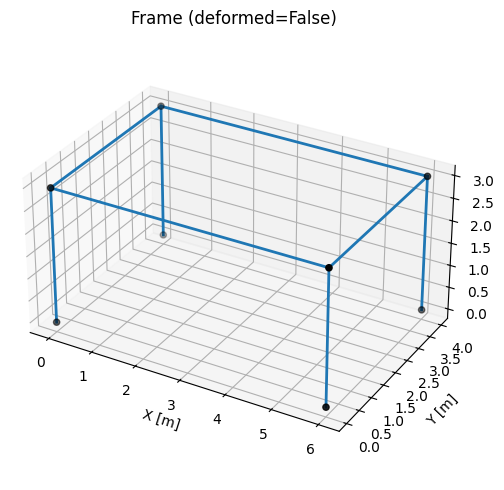

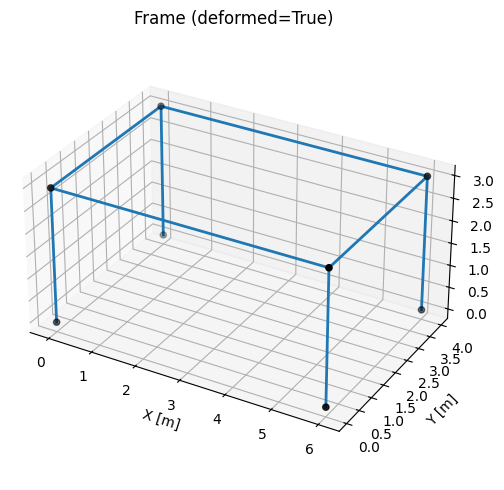

In [86]:
from mpl_toolkits.mplot3d import Axes3D

def plot_frame(deformed=False, scale=1.0):
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')

    # Get displaced coordinates if requested
    dcoords = {}
    for n, (x, y, z) in coords.items():
        if deformed:
            dx, dy, dz, *_ = ops.nodeDisp(n)
            dcoords[n] = (x + scale*dx, y + scale*dy, z + scale*dz)
        else:
            dcoords[n] = (x, y, z)

    # Plot elements
    for eid, (i, j) in elements.items():
        xi, yi, zi = dcoords[i]
        xj, yj, zj = dcoords[j]
        ax.plot([xi, xj], [yi, yj], [zi, zj], color='tab:blue', lw=2)

    # Plot nodes
    xs, ys, zs = zip(*[dcoords[n] for n in sorted(dcoords.keys())])
    ax.scatter(xs, ys, zs, color='black')

    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Frame (deformed={})'.format(deformed))
    ax.set_box_aspect([Lx, Ly, H])
    plt.tight_layout()
    plt.show()

plot_frame(deformed=False)
plot_frame(deformed=True, scale=50.0)  # exaggerate deformation
